In [ ]:
# packages
using Markdown
using InteractiveUtils
using NonlinearSolve
using Plots 
using StaticArrays
# files
using PKAssetPrices

# Defining models

A model can be easily defined via the @model macro, one must define @variables, @parameters and @equations

In [45]:
@model SimplePK2 begin
	@variables begin
		Y = "Output"
		ND = "Non debt-financed demand"
		D = "debt-financed demand"
		r = "interest rate"
		i = "policy rate"
		P = "price level"
		dL = "change in loans"
		dM = "change in money"
		dR = "change in reserves"
		W = "wage level"
		N = "employment"
		U = "unemployment rate"
	end

	@parameters begin
		b = 0.5, "consumption rate"
		c = 0.8, "credit rationing"
		d₀ = 5.0, "autonomuous  credit financed demand"
		d₁ = 8, "induced credit financed demand"
		i₀ = 0.01, "autonomuous policy rate"
		i₁ = 0.05, "inflation infuced policy rate"
		m = 0.15, "policy rate markup"
		k = 0.3, "resere share"
		n = 0.15, "firm markup"
		W₀ = 2.0, "autonomuous wages"
		h = 0.8, "bargaining power?"
		a = 0.8, "production induced employment "
		Nᶠ = 12.0, "total labour supply"
	end

	@equations begin
		Y == ND + c * D
		ND == b * Y
		D == d₀ - d₁ * r
		r == (1 + m) * i
		i == i₀ + i₁ * P
		dL == c * D
		dM == dL
		dR == k * dM
		P == (1 + n) * a * W
		W == W₀ - h * U
		N == a * Y
		U == 1 - N / Nᶠ
	end

	@curves begin
		IS(r) = (1/(1-b)) * (c * (d₀ - d₁ * r))
		IR(Y) = (1 + m) * (i₀ + i₁ * (1 + n) * a * (W₀ - h * (1 - (a * Y) / Nᶠ)))
		AD(P) = (1/(1-b)) * (c * (d₀ - d₁ * ((1 + m) * (i₀ + i₁ * P))))
		AS(Y) = (1 + n) * a * (W₀ - h * (1 - (a * Y) / Nᶠ))
	end

end
  

┌ Info: Expr[:(Y::Float64), :(ND::Float64), :(D::Float64), :(r::Float64), :(i::Float64), :(P::Float64), :(dL::Float64), :(dM::Float64), :(dR::Float64), :(W::Float64), :(N::Float64), :(U::Float64)]
└ @ PKAssetPrices /home/franzs/Schreibtisch/Arbeit/PKAssetPrices/src/model_macros.jl:212


param_descriptions (generic function with 1 method)

# Defining scenarios

With the @scenario macro you can easily set different parameters, the name must be the same as the model defined via the @model macro

In [46]:
scen1 = @scenario AssetPK2 begin
    b = 0.6
end

AssetPK2Model(AssetPK2Params(0.6, 0.8, 0.1, 5.0, 8.0, 0.01, 0.05, 0.15, 0.3, 0.15, 2.0, 0.8, 0.8, 12.0, 1.0, 0.5, 1.0, 1.0, 0.0, 0.5, 0.1, 0.03, 6.0), [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

Das Modell kann folgend gelöst werden

In [47]:
sol = PKAssetPrices.solve_model(AssetPK2Model())

PKAssetPrices.AssetPK2Solution(PKAssetPrices.AssetPK2SolutionVar(6.490410222314374, 3.245205111157187, 4.253667114342216, 0.08112313974541127, 0.09329161070722296, 1.4224627949082254, 3.616011232267954, 3.616011232267954, 1.084803369680386, 1.5461552118567667, 5.1923281778515, 0.5673059851790416, 0.37080612111076644, 0.7416122422215329, 0.9640977318179894, 0.7692293195453969, 0.09820488659089947, 0.7629193878889233), BalanceSheet[PKAssetPrices.AssetPK2Private(3.616011232267954, 3.616011232267954), PKAssetPrices.AssetPK2Banks(3.616011232267954, 1.084803369680386, 3.616011232267954, 1.084803369680386), PKAssetPrices.AssetPK2CentralBank(1.084803369680386, 1.084803369680386)])

Mit .sol.variable_name kann auf die gelöste Variable zugegriffen werden

In [48]:
sol.sol.Y

6.490410222314374

In [49]:
sol.sheets[2].reserves

1.084803369680386

## IS/IR Curve

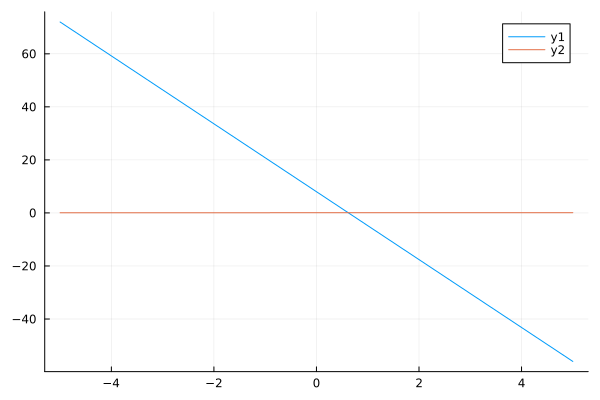

In [50]:
plot(x -> PKAssetPrices.SimplePKIS(x,SimplePKParams()))
plot!(x -> PKAssetPrices.SimplePKIR(x,SimplePKParams()))

### SimplePK vs. AssetPK

In [51]:
sa = PKAssetPrices.solve_model(AssetPKModel())
so = PKAssetPrices.solve_model(AssetPK2Model())


PKAssetPrices.AssetPK2Solution(PKAssetPrices.AssetPK2SolutionVar(6.490410222314374, 3.245205111157187, 4.253667114342216, 0.08112313974541127, 0.09329161070722296, 1.4224627949082254, 3.616011232267954, 3.616011232267954, 1.084803369680386, 1.5461552118567667, 5.1923281778515, 0.5673059851790416, 0.37080612111076644, 0.7416122422215329, 0.9640977318179894, 0.7692293195453969, 0.09820488659089947, 0.7629193878889233), BalanceSheet[PKAssetPrices.AssetPK2Private(3.616011232267954, 3.616011232267954), PKAssetPrices.AssetPK2Banks(3.616011232267954, 1.084803369680386, 3.616011232267954, 1.084803369680386), PKAssetPrices.AssetPK2CentralBank(1.084803369680386, 1.084803369680386)])

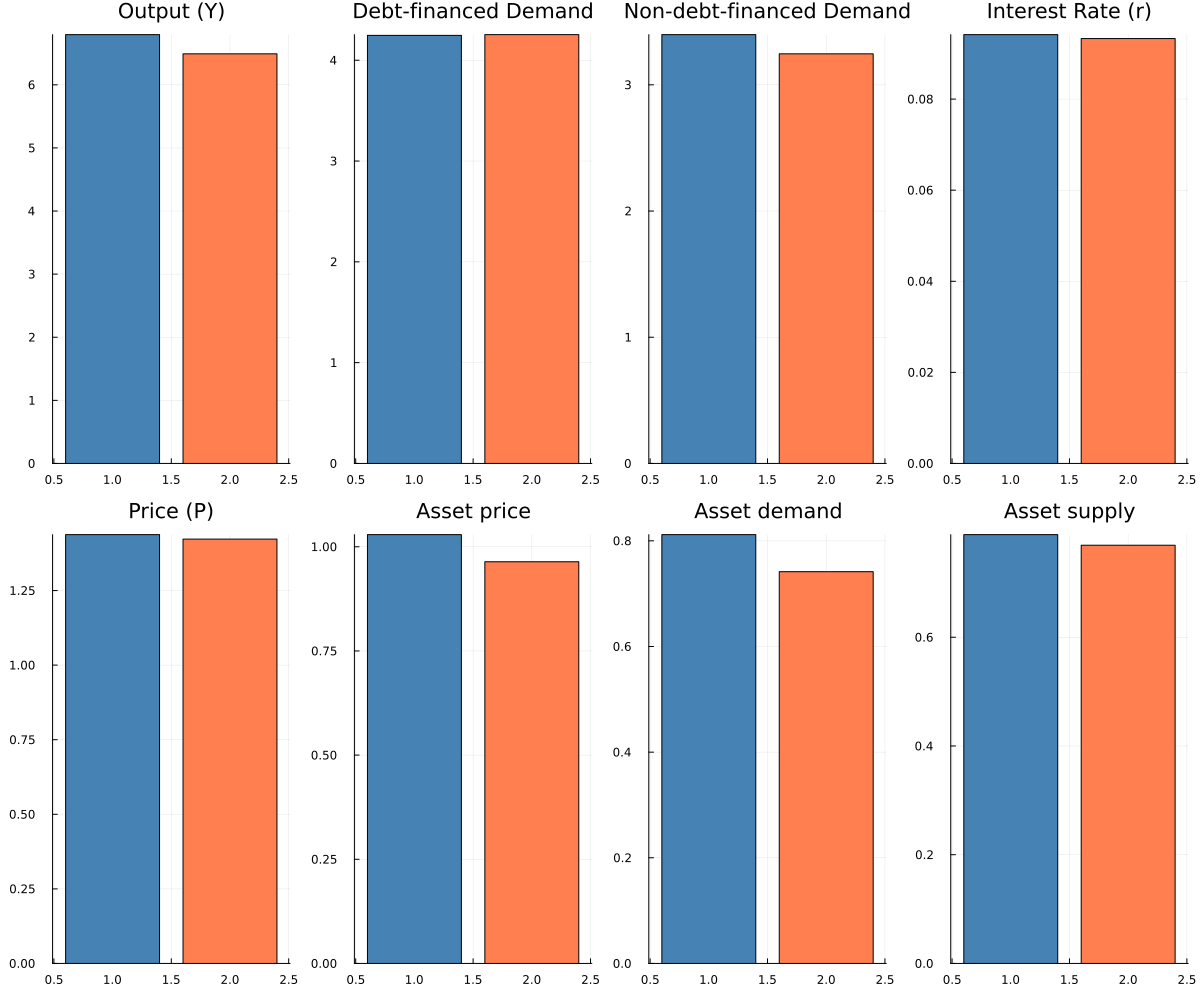

In [52]:
# Extract key variables from both solutions
sol_asset = sa.sol
sol_orig = so.sol

# Create comparison plot
p1 = bar([sol_asset.Y, sol_orig.Y], label=["AssetPK" "AssetPK2"], title="Output (Y)", fillcolor=[:steelblue, :coral])
p2 = bar([sol_asset.D, sol_orig.D], label=["AssetPK" "AssetPK2"], title="Debt-financed Demand", fillcolor=[:steelblue, :coral])
p3 = bar([sol_asset.ND, sol_orig.ND], label=["AssetPK" "AssetPK2"], title="Non-debt-financed Demand", color=[:steelblue, :coral])
p4 = bar([sol_asset.r, sol_orig.r], label=["AssetPK" "AssetPK2"], title="Interest Rate (r)", color=[:steelblue, :coral])
p5 = bar([sol_asset.P, sol_orig.P], label=["AssetPK" "AssetPK2"], title="Price (P)", color=[:steelblue, :coral])
p6 = bar([sol_asset.AP, sol_orig.AP], label=["AssetPK" "AssetPK2"], title="Asset price", color=[:steelblue, :coral])
p7 = bar([sol_asset.AD, sol_orig.AD], label=["AssetPK" "AssetPK2"], title="Asset demand", color=[:steelblue, :coral])
p8 = bar([sol_asset.AS, sol_orig.AS], label=["AssetPK" "AssetPK2"], title="Asset supply", color=[:steelblue, :coral])

plot(p1, p2, p3, p4, p5, p6, p7, p8, layout=(2,4), legend=false, size=(1200,1000))

## Balance Sheets
Es ist auch leicht möglich balance sheets zu generieren (siehe simplemodel.jl), diese werden automatisch befüllt und können über sol.sheets abgerufen werden

In [56]:
PKAssetPrices.display_balance_sheet.(sa.sheets)


Private
ASSETS                         | LIABILITIES                   
------------------------------------------------------------
Deposits: 3.8                  | Loans: 3.8                    
------------------------------------------------------------
TOTAL: 3.8                     | TOTAL: 3.8                    

Net Worth: 0.0

Banks
ASSETS                         | LIABILITIES                   
------------------------------------------------------------
Loans: 3.8                     | Central Bank Credit: 1.14     
Reserves: 1.14                 | Deposits: 3.8                 
------------------------------------------------------------
TOTAL: 4.94                    | TOTAL: 4.94                   

Net Worth: 0.0

CentralBank
ASSETS                         | LIABILITIES                   
------------------------------------------------------------
Central Bank Credit: 1.14      | Reserves: 1.14                
----------------------------------------------------------

3-element Vector{Nothing}:
 nothing
 nothing
 nothing

In [53]:
sum(PKAssetPrices.total_liabilities.(sol.sheets)) - sum(PKAssetPrices.total_assets.(sol.sheets))

0.0

### Alte Sachen, die nicht so recht geholfen haben ein dynamisches Environment bereitzustellen

In [16]:
using PyCall

@pyimport ipywidgets as widgets
@pyimport IPython.display as Pdisplay

# Create sliders
c_slider = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="c")
b_slider = widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="b")
d0_slider = widgets.FloatSlider(min=0, max=10, step=0.1, value=5.0, description="d0")

# Display
Pdisplay.display(widgets.VBox([c_slider, b_slider, d0_slider]))

ArgumentError: ArgumentError: Package PyCall not found in current path.
- Run `import Pkg; Pkg.add("PyCall")` to install the PyCall package.

In [17]:
using IJulia
using PyCall

Pwidgets = pyimport("ipywidgets")

# Create sliders
c_slider = Pwidgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="c")
b_slider = Pwidgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description="b")
d0_slider = Pwidgets.FloatSlider(min=0, max=10, step=0.1, value=5.0, description="d0")

# Display (this should work in IJulia)
vbox=display(Pwidgets.VBox([c_slider, b_slider, d0_slider]))

Main.IJulia.display(vbox)
display(vbox)

ArgumentError: ArgumentError: Package IJulia not found in current path.
- Run `import Pkg; Pkg.add("IJulia")` to install the IJulia package.

In [18]:
using WGLMakie, Makie

a = Observable(1)
b = Observable(1)

f(a, b) = sin(a*b)

fig = Figure()

ax = Axis(fig[1, 1])
lines!(ax, 0..10, x -> sin(a[] * x))

sl1 = Slider(fig[2, 1], range=1:5, startvalue=1)
sl2 = Slider(fig[3, 1], range=1:5, startvalue=1)

on(sl1.value) do v
    a[] = v
end

on(sl2.value) do v
    b[] = v
end

fig

ArgumentError: ArgumentError: Package WGLMakie not found in current path.
- Run `import Pkg; Pkg.add("WGLMakie")` to install the WGLMakie package.

In [19]:
f(a, b) = sin(a*b)

@bind a Slider(1:5)
@bind b Slider(1:5)

f(a, b)


LoadError: LoadError: UndefVarError: `@bind` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /home/franzs/Schreibtisch/Arbeit/PKAssetPrices/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:3

In [20]:
begin
	plot(range(0,10,10),y -> as_curve(y,params), label = "AS", title = "AS-AD curve")
	plot!(range(0.10,10), p -> ad_curve(p,params), label = "AD")
end

UndefVarError: UndefVarError: `as_curve` not defined in `Main`
Suggestion: check for spelling errors or missing imports.